# 01 - Exploratory Data Analysis sul dataset di Object Detection

Questo notebook esplora il dataset Hugging Face `keremberke/german-traffic-sign-detection`, usato per l'Esercizio 3.3 (object detection).

E' un dataset **diverso** da quello di classificazione GTSRB usato nell'Esercizio 2: qui le immagini sono fotogrammi stradali completi (non ritagliati attorno a un singolo segnale) e possono contenere zero, uno o piu' segnali annotati con bounding box.

L'obiettivo, come nell'EDA dell'Esercizio 2, e' raccogliere osservazioni su dimensione del dataset, distribuzione degli oggetti, delle classi e delle bounding box, prima di passare al training del detector.

## Setup

Carichiamo i tre split ufficiali (train/validation/test) direttamente dal dataset Hugging Face.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from datasets import load_dataset

notebook_dir = Path.cwd()
lab_root = notebook_dir.parent if notebook_dir.name == "exercise_3_gtsrb_detection" else Path("DLA_LAB1")
cache_dir = lab_root / "_data"

HF_DATASET = "keremberke/german-traffic-sign-detection"
HF_CONFIG = "full"

splits = {"train": "train", "validation": "validation", "test": "test"}
data = {
    name: load_dataset(HF_DATASET, name=HF_CONFIG, split=hf_split, cache_dir=str(cache_dir))
    for name, hf_split in splits.items()
}

cat_names = data["train"].features["objects"].feature["category"].names

for name, ds in data.items():
    print(f"{name}: {len(ds)} immagini")
print(f"Numero di categorie definite: {len(cat_names)}")

train: 383 immagini
validation: 108 immagini
test: 54 immagini
Numero di categorie definite: 43


**Osservazioni**

- Conto 383 immagini di train, 108 di validation, 54 di test (545 totali).
- Il dataset di classificazione contiene 26.640 immagini di train (39.270 includendo il test): il dataset detection è quindi molto più piccolo.
- Uso gli split ufficiali del dataset, senza suddivisioni aggiuntive.
- Noto che il test set e' di sole 54 immagini: ogni singolo errore pesa circa il 2% sulla metrica finale.

## Distribuzione degli oggetti per immagine

A differenza della classificazione (sempre 1 oggetto per immagine per costruzione), qui il numero di segnali annotati per immagine e' variabile, incluse immagini senza alcun segnale (scene negative).

count    545.000000
mean       1.563303
std        0.937442
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
dtype: float64

train: 29/383 immagini senza oggetti annotati (7.6%)
validation: 6/108 immagini senza oggetti annotati (5.6%)
test: 4/54 immagini senza oggetti annotati (7.4%)


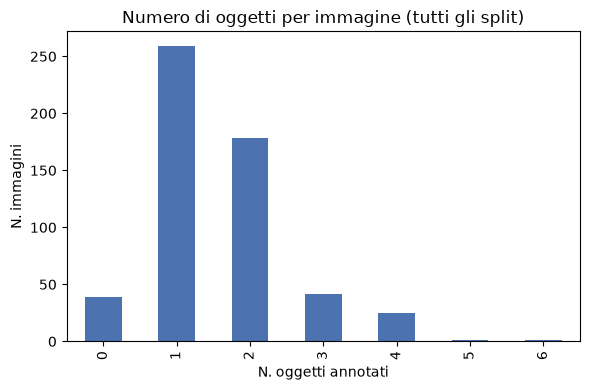

In [2]:
n_objects_by_split = {
    name: [len(rec["objects"]["category"]) for rec in ds]
    for name, ds in data.items()
}

all_n_objects = sum(n_objects_by_split.values(), [])
n_objects_series = pd.Series(all_n_objects)

print(n_objects_series.describe())
print()
for name, values in n_objects_by_split.items():
    n_negative = sum(1 for v in values if v == 0)
    print(f"{name}: {n_negative}/{len(values)} immagini senza oggetti annotati ({100 * n_negative / len(values):.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
n_objects_series.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Numero di oggetti per immagine (tutti gli split)")
ax.set_xlabel("N. oggetti annotati")
ax.set_ylabel("N. immagini")
plt.tight_layout()
plt.show()

**Osservazioni**

- Rilevo mediana 1 e massimo 6 oggetti per immagine.
- Conto 29/383 immagini senza oggetti annotati nel train, 6/108 in validation, 4/54 nel test. Totale: 39/545 (7,2%).
- Verifico che il parser (`src/detection_data.py`) restituisce un tensore `boxes` di forma `(0, 4)` per queste immagini.

## Distribuzione delle categorie (classi)

Osserviamo quali classi di segnali sono rappresentate nel training set e con quale frequenza.

Categorie osservate nel train: 41 su 43 definite
Occorrenze minime: 1, massime: 50
Categorie mai osservate nel train: ['animals', 'restriction ends']


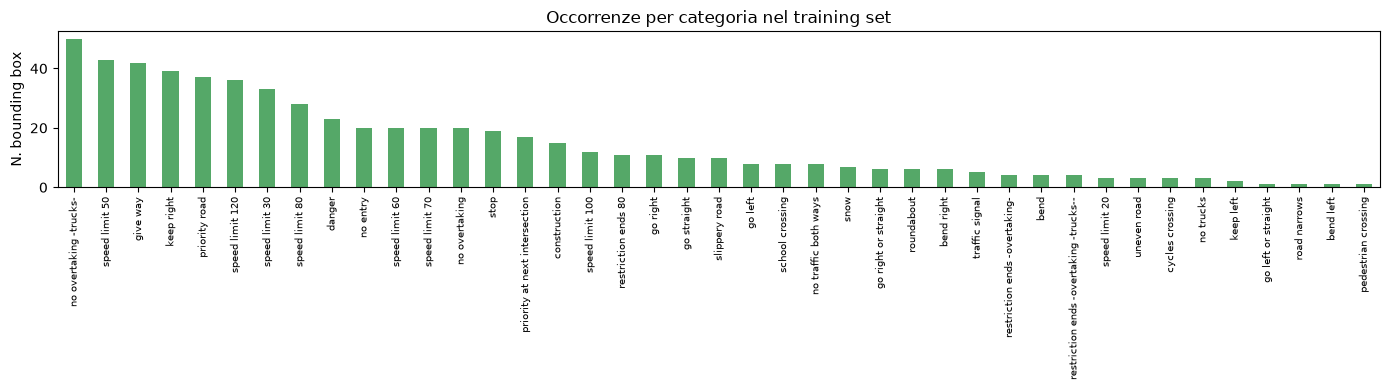

In [3]:
category_counts = {}
for rec in data["train"]:
    for cat in rec["objects"]["category"]:
        name = cat_names[cat]
        category_counts[name] = category_counts.get(name, 0) + 1

category_series = pd.Series(category_counts).sort_values(ascending=False)

print(f"Categorie osservate nel train: {len(category_series)} su {len(cat_names)} definite")
print(f"Occorrenze minime: {category_series.min()}, massime: {category_series.max()}")
missing = sorted(set(cat_names) - set(category_series.index))
print(f"Categorie mai osservate nel train: {missing}")

fig, ax = plt.subplots(figsize=(14, 4))
category_series.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Occorrenze per categoria nel training set")
ax.set_ylabel("N. bounding box")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

**Osservazioni**

- Su 43 categorie definite, ne osservo 41 nel training set.
- Rilevo 2 categorie assenti dal training.
- Conto occorrenze per categoria comprese tra 1 e 50.
- Considero il mAP per-classe sulle categorie con poche occorrenze, o assenti dal training, non affidabile.

## Dimensioni delle immagini e delle bounding box

Verifichiamo se le immagini hanno dimensioni fisse e quanto sono grandi i segnali rispetto al fotogramma completo.

Dimensioni immagine uniche nel dataset: {(1360, 800)}

                w           h  aspect_ratio
count  852.000000  852.000000    852.000000
mean    43.395540   42.751174      1.012951
std     22.349686   21.503074      0.067929
min     16.000000   16.000000      0.586207
25%     27.000000   27.000000      0.982143
50%     38.000000   37.000000      1.000000
75%     53.000000   52.000000      1.043972
max    127.000000  128.000000      1.266667

Area della bbox come frazione dell'area immagine:
count    852.000000
mean       0.002141
std        0.002458
min        0.000235
25%        0.000670
50%        0.001258
75%        0.002533
max        0.013905
Name: area_frac, dtype: float64


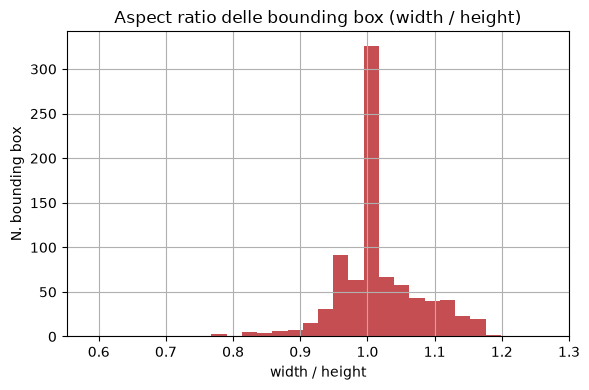

In [4]:
image_sizes = set()
bbox_rows = []
for name, ds in data.items():
    for rec in ds:
        image_sizes.add((rec["width"], rec["height"]))
        for bbox in rec["objects"]["bbox"]:
            x, y, w, h = bbox
            bbox_rows.append({
                "split": name, "w": w, "h": h,
                "aspect_ratio": w / h if h > 0 else np.nan,
                "area_frac": (w * h) / (rec["width"] * rec["height"]),
            })

bbox_df = pd.DataFrame(bbox_rows)

print(f"Dimensioni immagine uniche nel dataset: {image_sizes}")
print()
print(bbox_df[["w", "h", "aspect_ratio"]].describe())
print()
print("Area della bbox come frazione dell'area immagine:")
print(bbox_df["area_frac"].describe())

fig, ax = plt.subplots(figsize=(6, 4))
bbox_df["aspect_ratio"].hist(bins=30, ax=ax, color="#C44E52")
ax.set_title("Aspect ratio delle bounding box (width / height)")
ax.set_xlabel("width / height")
ax.set_ylabel("N. bounding box")
plt.tight_layout()
plt.show()

**Osservazioni**

- Verifico che tutte le immagini hanno dimensione fissa 1360x800 px.
- Misuro una dimensione media delle bounding box di 43x43 px.
- Calcolo un'area media della bounding box pari allo 0,21% dell'area totale dell'immagine.
- Rilevo un aspect ratio medio di ~1,0 (min 0,59, max 1,27).

## Ispezione visiva

Visualizziamo alcuni esempi rappresentativi: un caso tipico, il caso con il maggior numero di oggetti annotati, e un'immagine negativa (senza segnali).

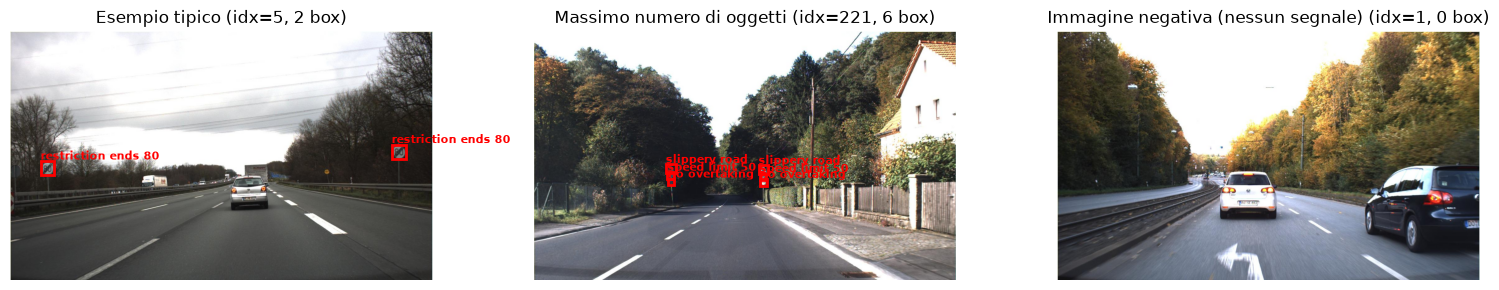

In [5]:
train_ds = data["train"]

idx_typical = 5
idx_max_objects = max(range(len(train_ds)), key=lambda i: len(train_ds[i]["objects"]["category"]))  # indice dell'immagine con piu' bounding box annotate
idx_negative = next(i for i in range(len(train_ds)) if len(train_ds[i]["objects"]["category"]) == 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
examples = [
    (idx_typical, "Esempio tipico"),
    (idx_max_objects, "Massimo numero di oggetti"),
    (idx_negative, "Immagine negativa (nessun segnale)"),
]
for ax, (idx, title) in zip(axes, examples):
    rec = train_ds[idx]
    ax.imshow(rec["image"])
    for bbox, cat in zip(rec["objects"]["bbox"], rec["objects"]["category"]):
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 5, cat_names[cat], color="red", fontsize=8, weight="bold")
    n_obj = len(rec["objects"]["category"])
    ax.set_title(f"{title} (idx={idx}, {n_obj} box)")
    ax.axis("off")
plt.tight_layout()
plt.show()

**Osservazioni**

- Osservo fotogrammi di scene di guida reali (autostrada, strada extraurbana).
- Noto segnali spesso piccoli e distanti dalla camera.
- Rilevo casi con piu' segnali raggruppati sullo stesso palo.
- Verifico un caso di immagine negativa: strada senza alcun segnale visibile, nessuna bounding box annotata.

## Sintesi finale

- Dataset: 545 immagini (383/108/54).
- Immagini negative: 39/545 (7,2%).
- Categorie osservate nel train: 41/43, occorrenze da 1 a 50.
- Dimensione media bounding box: 43x43 px su frame 1360x800 px (0,21% dell'area immagine).